In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf


In [ ]:
! pip install ta

In [ ]:
import ta



**DATA COLLECTION**

What it does?

Downloads historical Sensex OHLCV data:

Open
High
Low
Close
Volume
Why

Historical market data is required to:

Analyze trends
Generate indicators
Train ML models
Justification

Yahoo Finance provides reliable historical market data and is widely used for academic and financial analytics projects.

In [ ]:
df = yf.download("^BSESN", start="2020-01-01", end="2026-06-23")
df.reset_index(inplace=True)
df.to_csv("sensex_raw.csv", index=False)

df.tail()

/tmp/ipykernel_19805/1148111621.py:1: FutureWarning:

YF.download() has changed argument auto_adjust default to True

[*********************100%***********************]  1 of 1 completed


Price,Date,Close,High,Low,Open,Volume
Ticker,,^BSESN,^BSESN,^BSESN,^BSESN,^BSESN
1591,2026-06-16,76808.476562,76846.742188,76443.343750,76526.773438,12700
1592,2026-06-17,77155.617188,77218.992188,76768.492188,77080.093750,17800
1593,2026-06-18,77409.976562,77492.328125,76953.000000,77131.656250,17900
1594,2026-06-19,76802.898438,76901.648438,76469.718750,76852.859375,18000
1595,2026-06-22,77094.070312,77325.562500,77008.023438,77160.671875,13400


In [ ]:
df = df.drop(df.index[0])
df.head()

Price,Date,Close,High,Low,Open,Volume
Ticker,,^BSESN,^BSESN,^BSESN,^BSESN,^BSESN
1,2020-01-03,41464.609375,41636.179688,41348.679688,41634.511719,8900
2,2020-01-06,40676.628906,41378.339844,40613.960938,41378.339844,8700
3,2020-01-07,40869.468750,41230.140625,40727.371094,40983.039062,11900
4,2020-01-08,40817.738281,40866.359375,40476.550781,40574.828125,18200
5,2020-01-09,41452.351562,41482.121094,41175.718750,41216.671875,7800


In [ ]:
df.columns = df.columns.get_level_values(0)

In [ ]:
df.head()

Price,Date,Close,High,Low,Open,Volume
1,2020-01-03,41464.609375,41636.179688,41348.679688,41634.511719,8900
2,2020-01-06,40676.628906,41378.339844,40613.960938,41378.339844,8700
3,2020-01-07,40869.468750,41230.140625,40727.371094,40983.039062,11900
4,2020-01-08,40817.738281,40866.359375,40476.550781,40574.828125,18200
5,2020-01-09,41452.351562,41482.121094,41175.718750,41216.671875,7800


In [ ]:
df.columns.name = None

In [ ]:
df.head()

,Date,Close,High,Low,Open,Volume
1,2020-01-03,41464.609375,41636.179688,41348.679688,41634.511719,8900
2,2020-01-06,40676.628906,41378.339844,40613.960938,41378.339844,8700
3,2020-01-07,40869.468750,41230.140625,40727.371094,40983.039062,11900
4,2020-01-08,40817.738281,40866.359375,40476.550781,40574.828125,18200
5,2020-01-09,41452.351562,41482.121094,41175.718750,41216.671875,7800


In [ ]:
df.drop_duplicates()

,Date,Close,High,Low,Open,Volume
1,2020-01-03,41464.609375,41636.179688,41348.679688,41634.511719,8900
2,2020-01-06,40676.628906,41378.339844,40613.960938,41378.339844,8700
3,2020-01-07,40869.468750,41230.140625,40727.371094,40983.039062,11900
4,2020-01-08,40817.738281,40866.359375,40476.550781,40574.828125,18200
5,2020-01-09,41452.351562,41482.121094,41175.718750,41216.671875,7800
...,...,...,...,...,...,...
1591,2026-06-16,76808.476562,76846.742188,76443.343750,76526.773438,12700
1592,2026-06-17,77155.617188,77218.992188,76768.492188,77080.093750,17800
1593,2026-06-18,77409.976562,77492.328125,76953.000000,77131.656250,17900
1594,2026-06-19,76802.898438,76901.648438,76469.718750,76852.859375,18000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1595 entries, 1 to 1595
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    1595 non-null   datetime64[ns]
 1   Close   1595 non-null   float64       
 2   High    1595 non-null   float64       
 3   Low     1595 non-null   float64       
 4   Open    1595 non-null   float64       
 5   Volume  1595 non-null   int64         
dtypes: datetime64[ns](1), float64(4), int64(1)
memory usage: 74.9 KB


In [ ]:
# Creating  proper datetime column for sorting
df['MonthYear_dt'] = df['Date'].dt.to_period('M').dt.to_timestamp()

df_monthly = df.groupby('MonthYear_dt')['Close'].mean().reset_index()

# Creating display label
df_monthly['MonthYear'] = df_monthly['MonthYear_dt'].dt.strftime('%b %Y')

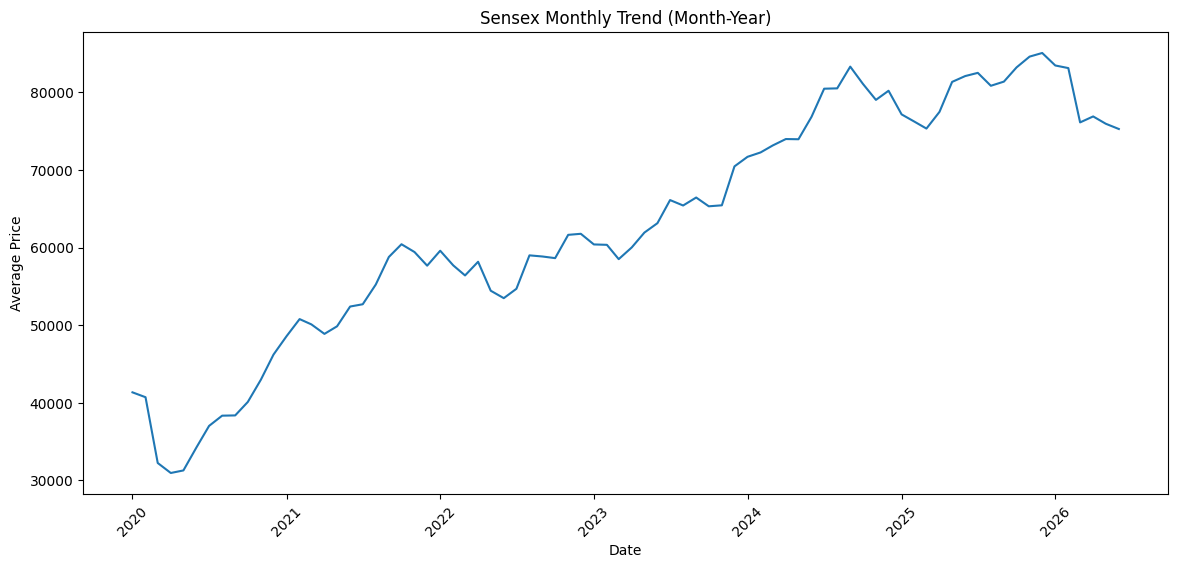

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))

plt.plot(df_monthly['MonthYear_dt'], df_monthly['Close'])

plt.title("Sensex Monthly Trend (Month-Year)")
plt.xlabel("Date")
plt.ylabel("Average Price")

plt.xticks(rotation=45)
plt.show()

In [ ]:
import plotly.graph_objects as go

In [ ]:
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=df_monthly['MonthYear_dt'],
    y=df_monthly['Close'],
    mode='lines+markers+text',
    name='Sensex',
    line=dict(width=2),
    marker=dict(size=2),
    textfont=dict(size=4),
    text=df_monthly['Close'].round(2),
    textposition='top center'
))

fig.update_layout(
    title="Sensex Monthly Trend (Interactive with Data Points)",
    xaxis_title="Date",
    yaxis_title="Price",
    template="plotly_white"
)

fig.show()

In [ ]:
df['Return'] = df['Close'].pct_change()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1595 entries, 1 to 1595
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Date          1595 non-null   datetime64[ns]
 1   Close         1595 non-null   float64       
 2   High          1595 non-null   float64       
 3   Low           1595 non-null   float64       
 4   Open          1595 non-null   float64       
 5   Volume        1595 non-null   int64         
 6   MonthYear_dt  1595 non-null   datetime64[ns]
 7   Return        1594 non-null   float64       
dtypes: datetime64[ns](2), float64(5), int64(1)
memory usage: 99.8 KB


In [ ]:
df.head()


,Date,Close,High,Low,Open,Volume,MonthYear_dt,Return
1,2020-01-03,41464.609375,41636.179688,41348.679688,41634.511719,8900,2020-01-01,NaN
2,2020-01-06,40676.628906,41378.339844,40613.960938,41378.339844,8700,2020-01-01,-0.019004
3,2020-01-07,40869.468750,41230.140625,40727.371094,40983.039062,11900,2020-01-01,0.004741
4,2020-01-08,40817.738281,40866.359375,40476.550781,40574.828125,18200,2020-01-01,-0.001266
5,2020-01-09,41452.351562,41482.121094,41175.718750,41216.671875,7800,2020-01-01,0.015547


In [ ]:
df['Return'] = df['Return'].fillna(0)

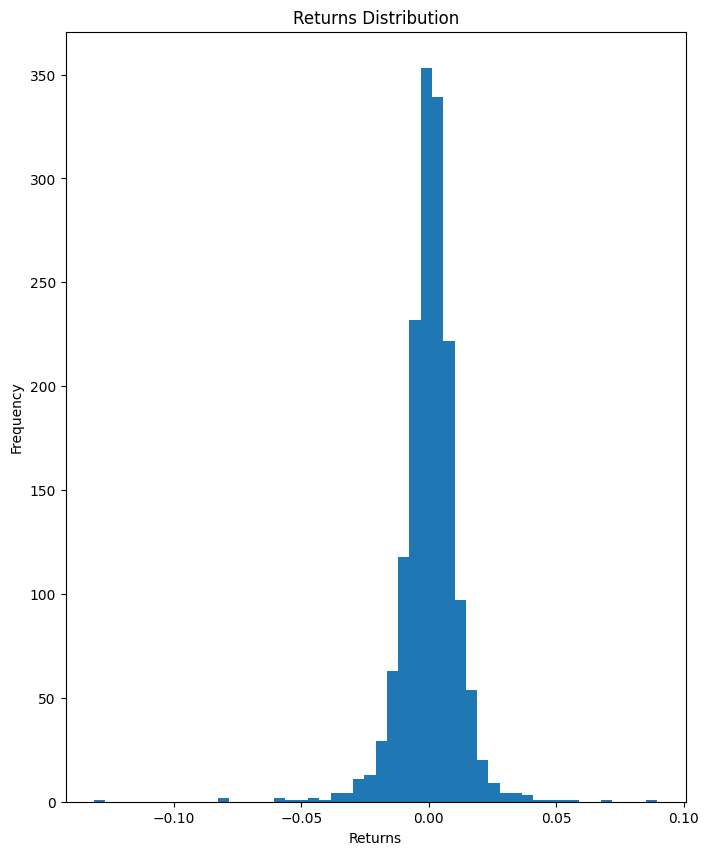

In [ ]:
plt.figure(figsize = (8,10))
plt.hist(df['Return'], bins = 50) #LINE CHART  #YEAR WITH MONTH
plt.title('Returns Distribution')
plt.xlabel('Returns')
plt.ylabel('Frequency')
plt.show()

In [ ]:
macd = ta.trend.MACD(df['Close'])

df['MACD'] = macd.macd()
df['MACD_signal'] = macd.macd_signal()

In [ ]:
df['RSI'] = ta.momentum.RSIIndicator(df['Close']).rsi()

In [ ]:
bb = ta.volatility.BollingerBands(df['Close'])

df['BB_high'] = bb.bollinger_hband()
df['BB_low'] = bb.bollinger_lband()

In [ ]:
df['SMA_20'] = df['Close'].rolling(20).mean()
df['EMA_20'] = df['Close'].ewm(span=20).mean()

df['SMA_50'] = df['Close'].rolling(50).mean()
df['SMA_100'] = df['Close'].rolling(100).mean()
df['SMA_200'] = df['Close'].rolling(200).mean()

df['EMA_50'] = df['Close'].ewm(span=50).mean()
df['EMA_100'] = df['Close'].ewm(span=100).mean()
df['EMA_200'] = df['Close'].ewm(span=200).mean()

In [ ]:
df.dropna(inplace=True)

In [ ]:
df.head().T

,220,221,222,223,224
Date,2020-11-19 00:00:00,2020-11-20 00:00:00,2020-11-23 00:00:00,2020-11-24 00:00:00,2020-11-25 00:00:00
Close,43599.960938,43882.25,44077.148438,44523.019531,43828.101562
High,44230.0,44013.019531,44271.148438,44601.628906,44825.371094
Low,43518.109375,43453.75,43747.21875,44247.121094,43757.96875
Open,43902.238281,43732.140625,44164.171875,44341.191406,44749.730469
Volume,24100,17100,17800,17900,19100
MonthYear_dt,2020-11-01 00:00:00,2020-11-01 00:00:00,2020-11-01 00:00:00,2020-11-01 00:00:00,2020-11-01 00:00:00
Return,-0.01313,0.006475,0.004441,0.010116,-0.015608
MACD,1118.005491,1120.141698,1124.59767,1150.840953,1102.851882
MACD_signal,899.865936,943.921089,980.056405,1014.213315,1031.941028


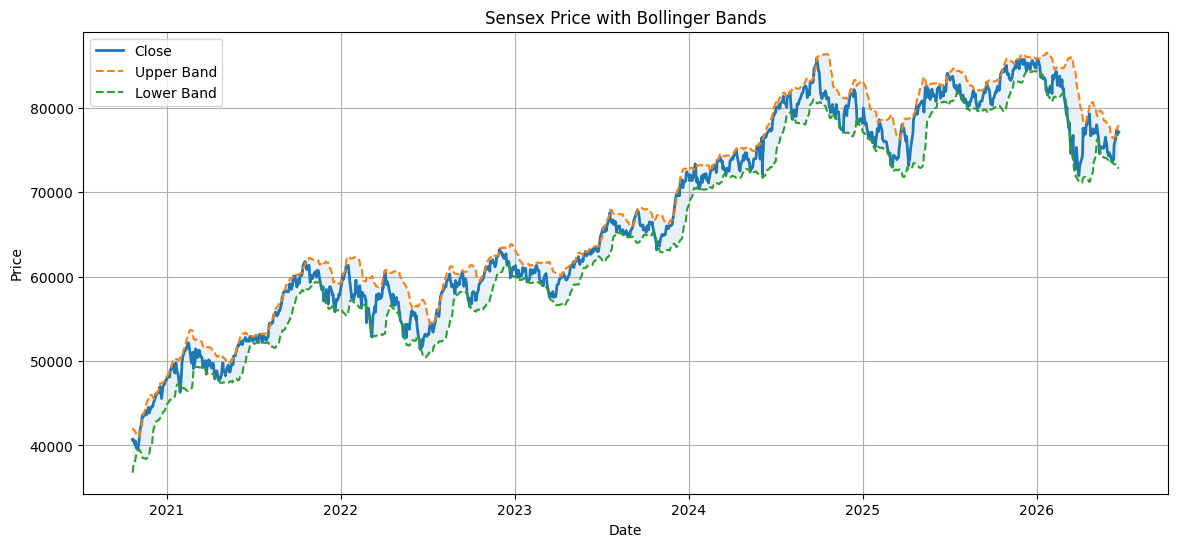

In [ ]:
plt.figure(figsize=(14,6))

plt.plot(df['Date'], df['Close'], label='Close', linewidth=2)
plt.plot(df['Date'], df['BB_high'], linestyle='--', label='Upper Band')
plt.plot(df['Date'], df['BB_low'], linestyle='--', label='Lower Band')


plt.fill_between(df['Date'], df['BB_low'], df['BB_high'], alpha=0.1)

plt.title("Sensex Price with Bollinger Bands")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid()

plt.show()

In [ ]:
fig = go.Figure()

# RSI Line
fig.add_trace(go.Scatter(
    x=df['Date'],
    y=df['RSI'],
    mode='lines',
    name='RSI',
    line=dict(color='purple', width=2)
))

# Overbought line
fig.add_hline(
    y=70,
    line_dash="dash",
    line_color="red",
    annotation_text="Overbought (>70)",
    annotation_position="top left"
)

# Oversold line
fig.add_hline(
    y=30,
    line_dash="dash",
    line_color="green",
    annotation_text="Oversold (<30)",
    annotation_position="bottom left"
)

# Highlight Overbought Zone
fig.add_trace(go.Scatter(
    x=df['Date'],
    y=df['RSI'],
    fill='tozeroy',
    mode='none',
    fillcolor='rgba(255,0,0,0.15)',
    showlegend=False
))

fig.update_layout(
    title="RSI Indicator",
    xaxis_title="Date",
    yaxis_title="RSI",
    template="plotly_white",
    hovermode='x unified'
)

fig.show()  #BUY SELL SIGNAL GENERATE AND WHEN TO HOLD

In [ ]:
print(df.columns)

Index(['Date', 'Close', 'High', 'Low', 'Open', 'Volume', 'MonthYear_dt',
       'Return', 'MACD', 'MACD_signal', 'RSI', 'BB_high', 'BB_low', 'SMA_20',
       'EMA_20', 'SMA_50', 'SMA_100', 'SMA_200', 'EMA_50', 'EMA_100',
       'EMA_200'],
      dtype='object')


In [ ]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go

df['Date'] = pd.to_datetime(df['Date'])

df['Returns'] = df['Close'].pct_change()

df['Volatility'] = df['Returns'].rolling(window=20).std() * np.sqrt(252)

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=df['Date'],
    y=df['Volatility'],
    mode='lines',
    name='20-Day Volatility',
    line=dict(width=2)
))

fig.update_layout(
    title='20-Day Rolling Volatility',
    xaxis_title='Date',
    yaxis_title='Volatility',
    template='plotly_white',
    hovermode='x unified'
)

fig.show()

In [ ]:

df['Date'] = pd.to_datetime(df['Date'])

df['Returns'] = df['Close'].pct_change()

df['Cumulative_Return'] = (1 + df['Returns']).cumprod()

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=df['Date'],
    y=df['Cumulative_Return'],
    mode='lines',
    name='Cumulative Return',
    line=dict(width=2)
))

fig.update_layout(
    title="Cumulative Returns Over Time",
    xaxis_title="Date",
    yaxis_title="Growth of ₹1 Investment",
    template="plotly_white"
)

fig.show()

In [ ]:
golden = df[df['SMA_50'] > df['SMA_200']]

fig = go.Figure()

# SMA 50
fig.add_trace(go.Scatter(
    x=df['Date'],
    y=df['SMA_50'],
    mode='lines',
    name='SMA 50'
))

# SMA 200
fig.add_trace(go.Scatter(
    x=df['Date'],
    y=df['SMA_200'],
    mode='lines',
    name='SMA 200'
))

# Golden Cross markers
fig.add_trace(go.Scatter(
    x=golden['Date'],
    y=golden['SMA_50'],
    mode='markers',
    name='Golden Cross',
    marker=dict(
        symbol='triangle-up',
        size=8
    )
))

fig.update_layout(
    title="Golden Cross Detection",
    xaxis_title="Date",
    yaxis_title="Price",
    template="plotly_white"
)

fig.show()

In [ ]:
import plotly.graph_objects as go

fig = go.Figure()

fig.add_trace(go.Bar(
    x=df['Date'],
    y=df['Volume'],
    name='Volume'
))

fig.update_layout(
    title="Trading Volume Analysis",
    xaxis_title="Date",
    yaxis_title="Volume",
    template="plotly_white"
)

fig.show()

In [ ]:
!pip install mplfinance

In [ ]:
df_candle = df.copy()
df_candle.set_index('Date', inplace=True)
df_recent = df_candle.tail(120)

In [ ]:
import plotly.graph_objects as go

fig = go.Figure()

# Candlestick
fig.add_trace(go.Candlestick(
    x=df_recent.index,
    open=df_recent['Open'],
    high=df_recent['High'],
    low=df_recent['Low'],
    close=df_recent['Close'],
    name='Candles'
))

# SMA 20
fig.add_trace(go.Scatter(
    x=df_recent.index,
    y=df_recent['SMA_20'],
    mode='lines',
    name='SMA 20'
))

# SMA 50
fig.add_trace(go.Scatter(
    x=df_recent.index,
    y=df_recent['SMA_50'],
    mode='lines',
    name='SMA 50'
))

# SMA 100
fig.add_trace(go.Scatter(
    x=df_recent.index,
    y=df_recent['SMA_100'],
    mode='lines',
    name='SMA 100'
))

# SMA 200
fig.add_trace(go.Scatter(
    x=df_recent.index,
    y=df_recent['SMA_200'],
    mode='lines',
    name='SMA 200'
))

fig.update_layout(
    title='Sensex Candlestick Chart with Moving Averages',
    xaxis_title='Date',
    yaxis_title='Price',
    template='plotly_white',
    xaxis_rangeslider_visible=False,
    height=700
)

fig.show()  #BUY SELL SIGNA, resistance support

In [ ]:
# creating a target varibale


df['Target'] = (df['Close'].shift(-1) > df['Close']).astype(int)

In [ ]:
df.dropna(inplace=True)

In [ ]:
X = df[['Open','High','Low','Close','Volume',
        'Return',
        'RSI',
        'MACD',
        'MACD_signal',
        'BB_high',
        'BB_low',
        'SMA_20',
        'SMA_50',
        'SMA_100',
        'SMA_200',
        'EMA_20',
        'EMA_50',
        'EMA_100',
        'EMA_200',
        'Volatility']]

y = df['Target'] #close hatana he

In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

X_scaled = scaler.fit_transform(X)

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    shuffle=False
)

In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

svm_model = SVC()

svm_model.fit(X_train, y_train)

svm_pred = svm_model.predict(X_test)

print("SVM Accuracy:", accuracy_score(y_test, svm_pred))

SVM Accuracy: 0.5362318840579711


| Accuracy | Meaning              |
| -------- | -------------------- |
| 50%      | Random guessing      |
| 55–65%   | Good realistic model |
| 70%+     | Usually overfitting  |


In [1]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier()

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

print("RF Accuracy:", accuracy_score(y_test, rf_pred))

NameError: name 'X_train' is not defined

| Model         | Accuracy |
| ------------- | -------- |
| SVM           | 54.85%   |
| Random Forest | 54.10%   |


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, svm_pred))

              precision    recall  f1-score   support

           0       0.53      0.87      0.66       140
           1       0.59      0.19      0.29       136

    accuracy                           0.54       276
   macro avg       0.56      0.53      0.47       276
weighted avg       0.56      0.54      0.48       276



In [ ]:
from sklearn.metrics import confusion_matrix
import plotly.express as px

cm = confusion_matrix(y_test, svm_pred)

fig = px.imshow(
    cm,
    text_auto=True,
    labels=dict(x="Predicted", y="Actual"),
    x=['Down','Up'],
    y=['Down','Up'],
    title="SVM Confusion Matrix"
)

fig.show()

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier()

rf_model.fit(X_train, y_train)

RandomForestClassifier()

In [ ]:
importance = rf_model.feature_importances_

feature_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
})

feature_df = feature_df.sort_values(by='Importance', ascending=False)

print(feature_df)

        Feature  Importance
5        Return    0.075622
4        Volume    0.069077
6           RSI    0.067767
19   Volatility    0.060692
8   MACD_signal    0.057279
7          MACD    0.054098
2           Low    0.050759
9       BB_high    0.049886
14      SMA_200    0.047341
3         Close    0.046613
0          Open    0.045559
1          High    0.043759
10       BB_low    0.043634
13      SMA_100    0.043473
18      EMA_200    0.041881
16       EMA_50    0.041624
12       SMA_50    0.040927
15       EMA_20    0.040413
17      EMA_100    0.040155
11       SMA_20    0.039441


In [ ]:
fig = px.bar(
    feature_df,
    x='Importance',
    y='Feature',
    orientation='h',
    title='Feature Importance'
)

fig.show()

In [ ]:
from sklearn.metrics import roc_curve, auc

rf_probs = rf_model.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, rf_probs)

roc_auc = auc(fpr, tpr)

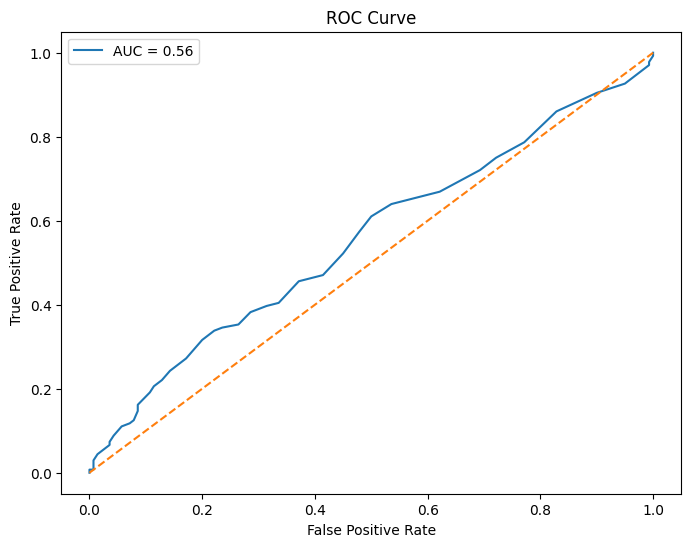

In [ ]:
plt.figure(figsize=(8,6))

plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.2f}')

plt.plot([0,1],[0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

In [ ]:
prediction_df = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': svm_pred
})

print(prediction_df.head(20))

    Actual  Predicted
0        0          1
1        1          0
2        1          0
3        0          0
4        0          0
5        0          0
6        1          0
7        0          0
8        1          0
9        1          0
10       0          0
11       0          0
12       1          0
13       0          0
14       0          0
15       0          0
16       1          0
17       1          0
18       1          0
19       1          0


In [ ]:
prediction_df['Predicted'] = prediction_df['Predicted'].map({
    1:'BUY',
    0:'SELL'
})

prediction_df['Actual'] = prediction_df['Actual'].map({
    1:'UP',
    0:'DOWN'
})

print(prediction_df.head(20))

   Actual Predicted
0    DOWN       BUY
1      UP      SELL
2      UP      SELL
3    DOWN      SELL
4    DOWN      SELL
5    DOWN      SELL
6      UP      SELL
7    DOWN      SELL
8      UP      SELL
9      UP      SELL
10   DOWN      SELL
11   DOWN      SELL
12     UP      SELL
13   DOWN      SELL
14   DOWN      SELL
15   DOWN      SELL
16     UP      SELL
17     UP      SELL
18     UP      SELL
19     UP      SELL


In [ ]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np

close_data = df[['Close']]

scaler = MinMaxScaler(feature_range=(0,1))

scaled_data = scaler.fit_transform(close_data)

In [ ]:
X = []
y = []

for i in range(60, len(scaled_data)):
    X.append(scaled_data[i-60:i, 0])
    y.append(scaled_data[i, 0])

X = np.array(X)
y = np.array(y)

In [ ]:
X = X.reshape(
    X.shape[0],
    X.shape[1],
    1
)

print(X.shape)

(1316, 60, 1)


In [ ]:
split = int(len(X) * 0.8)

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

In [ ]:
from tensorflow.keras.layers import Input

model = Sequential()

model.add(
    Input(shape=(X_train.shape[1],1))
)

model.add(
    LSTM(
        units=50,
        return_sequences=False
    )
)

model.add(Dense(25))
model.add(Dense(1))

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

model = Sequential()

model.add(
    LSTM(
        units=50,
        return_sequences=False,
        input_shape=(X_train.shape[1],1)
    )
)

model.add(Dense(25))
model.add(Dense(1))

model.compile(
    optimizer='adam',
    loss='mean_squared_error'
)

model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_3 (LSTM)                   │ (None, 50)             │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 25)             │         1,275 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            26 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,701 (45.71 KB)

 Trainable params: 11,701 (45.71 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_test, y_test)
)

Epoch 1/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 9s 76ms/step - loss: 0.0445 - val_loss: 0.0045
Epoch 2/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 3s 82ms/step - loss: 0.0027 - val_loss: 9.9105e-04
Epoch 3/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 3s 94ms/step - loss: 8.2465e-04 - val_loss: 0.0011
Epoch 4/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 4s 58ms/step - loss: 7.2576e-04 - val_loss: 0.0010
Epoch 5/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 61ms/step - loss: 7.1986e-04 - val_loss: 0.0011
Epoch 6/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - loss: 7.1496e-04 - val_loss: 8.9796e-04
Epoch 7/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 3s 52ms/step - loss: 6.9155e-04 - val_loss: 9.3748e-04
Epoch 8/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 7.0232e-04 - val_loss: 0.0011
Epoch 9/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 7.1582e-04 - val_loss: 8.9631e-04
Epoch 10/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - loss: 6.6646e-04 - val_loss: 8.1231e-04
Epoch 11/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 6.3654e-04 - val_loss: 8.7933e-04
Epo

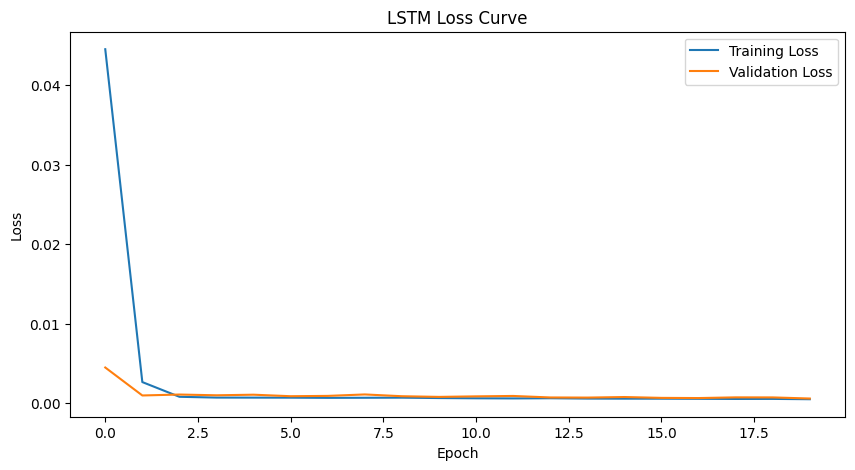

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(history.history['loss'],
         label='Training Loss')

plt.plot(history.history['val_loss'],
         label='Validation Loss')

plt.title('LSTM Loss Curve')

plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.legend()

plt.show()

In [ ]:
predictions = model.predict(X_test)

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step


In [ ]:
predictions = scaler.inverse_transform(predictions)

y_actual = scaler.inverse_transform(
    y_test.reshape(-1,1)
)

In [ ]:
from sklearn.metrics import mean_squared_error
import numpy as np

rmse = np.sqrt(
    mean_squared_error(
        y_actual,
        predictions
    )
)

print("RMSE:", rmse)

RMSE: 1041.4317978433498


In [ ]:
from sklearn.metrics import mean_absolute_percentage_error

mape = mean_absolute_percentage_error(
    y_actual,
    predictions
) * 100

print("MAPE:", mape)

MAPE: 0.9824715731792654


In [ ]:
import plotly.graph_objects as go

fig = go.Figure()

fig.add_trace(
    go.Scatter(
        y=y_actual.flatten(),
        name='Actual',
        mode='lines'
    )
)

fig.add_trace(
    go.Scatter(
        y=predictions.flatten(),
        name='Predicted',
        mode='lines'
    )
)

fig.update_layout(
    title='Actual vs Predicted Sensex Prices (LSTM)',
    xaxis_title='Time',
    yaxis_title='Sensex Price',
    template='plotly_white'
)

fig.show()

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense

In [ ]:
gru_model = Sequential()

gru_model.add(
    GRU(
        units=50,
        return_sequences=False,
        input_shape=(X_train.shape[1],1)
    )
)

gru_model.add(Dense(25))
gru_model.add(Dense(1))

gru_model.compile(
    optimizer='adam',
    loss='mean_squared_error'
)

gru_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 50)             │         7,950 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 25)             │         1,275 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            26 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,251 (36.14 KB)

 Trainable params: 9,251 (36.14 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
gru_history = gru_model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_test,y_test)
)

Epoch 1/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 5s 53ms/step - loss: 0.0535 - val_loss: 0.0300
Epoch 2/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - loss: 0.0041 - val_loss: 0.0032
Epoch 3/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - loss: 7.0106e-04 - val_loss: 3.7491e-04
Epoch 4/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - loss: 3.2614e-04 - val_loss: 3.6257e-04
Epoch 5/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 3.0461e-04 - val_loss: 3.5385e-04
Epoch 6/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 2.9891e-04 - val_loss: 3.5045e-04
Epoch 7/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - loss: 2.9466e-04 - val_loss: 3.4045e-04
Epoch 8/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - loss: 2.8451e-04 - val_loss: 3.2495e-04
Epoch 9/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 54ms/step - loss: 2.7974e-04 - val_loss: 3.1895e-04
Epoch 10/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - loss: 2.7330e-04 - val_loss: 3.3128e-04
Epoch 11/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 2.7022e-04 - val_loss: 4.

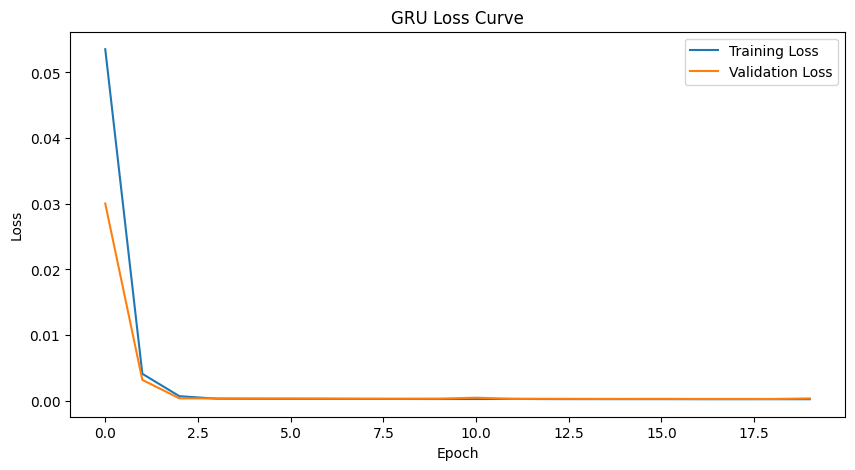

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(
    gru_history.history['loss'],
    label='Training Loss'
)

plt.plot(
    gru_history.history['val_loss'],
    label='Validation Loss'
)

plt.title('GRU Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.legend()

plt.show()

In [ ]:
gru_predictions = gru_model.predict(X_test)

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step


In [ ]:
gru_predictions = scaler.inverse_transform(
    gru_predictions
)

y_actual_gru = scaler.inverse_transform(
    y_test.reshape(-1,1)
)

In [ ]:
from sklearn.metrics import mean_squared_error
import numpy as np

gru_rmse = np.sqrt(
    mean_squared_error(
        y_actual_gru,
        gru_predictions
    )
)

print("GRU RMSE:", gru_rmse)

GRU RMSE: 805.2474771429276


In [ ]:
from sklearn.metrics import mean_absolute_percentage_error

gru_mape = mean_absolute_percentage_error(
    y_actual_gru,
    gru_predictions
) * 100

print("GRU MAPE:", gru_mape)

GRU MAPE: 0.7439974022352792


In [ ]:
import plotly.graph_objects as go

fig = go.Figure()

fig.add_trace(
    go.Scatter(
        y=y_actual_gru.flatten(),
        mode='lines',
        name='Actual'
    )
)

fig.add_trace(
    go.Scatter(
        y=gru_predictions.flatten(),
        mode='lines',
        name='GRU Predicted'
    )
)

fig.update_layout(
    title='GRU Actual vs Predicted Sensex Prices',
    xaxis_title='Time',
    yaxis_title='Sensex Price',
    template='plotly_white'
)

fig.show()

In [ ]:
comparison = pd.DataFrame({
    'Model':['SVM','Random Forest','LSTM','GRU'],
    'Metric':['Accuracy','Accuracy','MAPE','MAPE'],
    'Score':[
        54.85,
        54.10,
        mape,
        gru_mape
    ]
})

print(comparison)

           Model    Metric      Score
0            SVM  Accuracy  54.850000
1  Random Forest  Accuracy  54.100000
2           LSTM      MAPE   0.982472
3            GRU      MAPE   0.743997


In [ ]:
last_60_days = scaled_data[-60:]

In [ ]:


future_input = np.array(last_60_days)
future_input = future_input.reshape(1,60,1)

In [ ]:
future_price = gru_model.predict(future_input)

future_price = scaler.inverse_transform(
    future_price
)

print(
    "Predicted Next Day Sensex:",
    future_price[0][0]
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
Predicted Next Day Sensex: 75671.88


In [ ]:
future_predictions = []

current_batch = scaled_data[-60:].reshape(1,60,1)

for i in range(7):

    next_pred = gru_model.predict(
        current_batch,
        verbose=0
    )

    future_predictions.append(
        next_pred[0][0]
    )

current_batch = np.concatenate(
    (
        current_batch[:,1:,:],
        next_pred.reshape(1,1,1)
    ),
    axis=1
)

In [ ]:
future_predictions = scaler.inverse_transform(
    np.array(future_predictions).reshape(-1,1)
)

print(future_predictions)

[[75671.88]
 [75671.88]
 [75671.88]
 [75671.88]
 [75671.88]
 [75671.88]
 [75671.88]]


In [ ]:
import plotly.graph_objects as go

fig = go.Figure()

fig.add_trace(
    go.Scatter(
        x=list(range(1,8)),
        y=future_predictions.flatten(),
        mode='lines+markers',
        name='Forecast'
    )
)

fig.update_layout(
    title='7-Day Sensex Forecast (GRU)',
    xaxis_title='Future Trading Day',
    yaxis_title='Predicted Sensex',
    template='plotly_white'
)

fig.show()

In [ ]:
future_price = gru_model.predict(
    scaled_data[-60:].reshape(1,60,1)
)

future_price = scaler.inverse_transform(
    future_price
)

print(
    "Next Trading Day Forecast:",
    future_price[0][0]
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
Next Trading Day Forecast: 75671.88


In [ ]:
print(df.columns)

Index(['Date', 'Close', 'High', 'Low', 'Open', 'Volume', 'MonthYear_dt',
       'Return', 'MACD', 'MACD_signal', 'RSI', 'BB_high', 'BB_low', 'SMA_20',
       'EMA_20', 'SMA_50', 'SMA_100', 'SMA_200', 'EMA_50', 'EMA_100',
       'EMA_200', 'Returns', 'Volatility', 'Cumulative_Return', 'Target'],
      dtype='object')


In [ ]:
powerbi_df = df.copy()

powerbi_df.to_csv(
    'sensex_powerbi.csv',
    index=False
)

print("sensex_powerbi.csv exported")

sensex_powerbi.csv exported


In [ ]:
import pandas as pd

model_results = pd.DataFrame({
    'Model':['SVM','Random Forest','LSTM','GRU'],
    'Metric':['Accuracy','Accuracy','MAPE','MAPE'],
    'Score':[54.85,54.10,0.9617,0.7278]
})

model_results.to_csv(
    'model_results.csv',
    index=False
)

print("model_results.csv exported")

model_results.csv exported


In [ ]:
from google.colab import files

files.download('sensex_powerbi.csv')
files.download('model_results.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>